In [ ]:
#Change 1


In [ ]:
pip install google-play-scraper pandas

In [ ]:
import time
import pandas as pd
from google_play_scraper import Sort, reviews

# Mapping human-readable names to their exact Google Play Store package IDs
quick_comm_apps = {
    'Blinkit': 'com.grofers.customerapp',
    'Zepto':            'com.zeptoconsumerapp',
    'Big Basket': 'com.bigbasket.mobileapp',
    'Swiggy Instamart':   'in.swiggy.android.instamart',
    'JioMart': 'com.jpl.jiomart'
}

all_reviews_data = []

print(" Starting Quick-Commerce Scraping Pipeline...\n")

for app_name, package_id in quick_comm_apps.items():
    print(f"Scraping [{app_name}] (ID: {package_id})...")

    try:
        # Pulling a sample of 1000 reviews per app for analysis
        app_reviews, _ = reviews(
            package_id,
            lang='en',        # Target English reviews
            country='in',     # Targeted strictly to the Indian Google Play Store region
            sort=Sort.NEWEST, # Get the latest user feedback
            count=100000
        )

        if not app_reviews:
            print(f"No reviews found for {app_name}. Skipping.")
            continue

        # Convert to DataFrame and tag it
        df_app = pd.DataFrame(app_reviews)
        df_app['AppName'] = app_name
        df_app['packageId'] = package_id

        # Keep only the data crucial for sentiment analysis
        df_cleaned = df_app[['AppName', 'packageId', 'userName', 'score', 'at', 'content']]
        all_reviews_data.append(df_cleaned)

        print(f" Successfully grabbed {len(df_cleaned)} reviews.")

        # Pause to prevent hitting Google's rate-limiting thresholds
        time.sleep(3)

    except Exception as e:
        print(f"Error pulling data for {app_name}: {str(e)}")
        continue

# Combine into a single dataset
if all_reviews_data:
    master_df = pd.concat(all_reviews_data, ignore_index=True)

    print("\n" + "="*40)
    print(f"Dataset successfully generated! Total rows: {len(master_df)}")
    print("="*40)
    print(master_df['AppName'].value_counts())

    # Export to a unified CSV file
    master_df.to_csv('indian_quick_commerce_reviews.csv', index=False)
    print("\nSaved output as 'indian_quick_commerce_reviews.csv'")
else:
    print("No data collected.")

 Starting Quick-Commerce Scraping Pipeline...

Scraping [Blinkit] (ID: com.grofers.customerapp)...
 Successfully grabbed 100000 reviews.
Scraping [Zepto] (ID: com.zeptoconsumerapp)...
 Successfully grabbed 100000 reviews.
Scraping [Big Basket] (ID: com.bigbasket.mobileapp)...
 Successfully grabbed 100000 reviews.
Scraping [Swiggy Instamart] (ID: in.swiggy.android.instamart)...
 Successfully grabbed 100000 reviews.
Scraping [JioMart] (ID: com.jpl.jiomart)...
 Successfully grabbed 100000 reviews.

Dataset successfully generated! Total rows: 500000
AppName
Blinkit             100000
Zepto               100000
Big Basket          100000
Swiggy Instamart    100000
JioMart             100000
Name: count, dtype: int64

Saved output as 'indian_quick_commerce_reviews.csv'


In [ ]:
import time
import pandas as pd
from datetime import datetime, timedelta, timezone
from google_play_scraper import Sort, reviews

# --- Configure your date window here ---
MONTHS_BACK = 6  # Change to 7, 3, 12, etc.

end_date   = datetime.now(timezone.utc)
start_date = end_date - timedelta(days=30 * MONTHS_BACK)

print(f"Date window: {start_date.strftime('%Y-%m-%d')} → {end_date.strftime('%Y-%m-%d')}")

quick_comm_apps = {
    'Blinkit':                   'com.grofers.customerapp',
    'Zepto':            'com.zeptoconsumerapp',
    'Big Basket':                'com.bigbasket.mobileapp',
    'Swiggy Instamart':   'in.swiggy.android.instamart',
    'JioMart':                   'com.jpl.jiomart'
}

all_reviews_data = []
BATCH_SIZE = 5_000   # reviews fetched per API call
MAX_REVIEWS = 100_000  # upper safety cap per app

print("\n Starting Quick-Commerce Scraping Pipeline...\n")

for app_name, package_id in quick_comm_apps.items():
    print(f"Scraping [{app_name}] (ID: {package_id})...")

    app_reviews_filtered = []
    continuation_token   = None
    total_fetched        = 0
    stop_early           = False

    while not stop_early and total_fetched < MAX_REVIEWS:
        try:
            batch, continuation_token = reviews(
                package_id,
                lang='en',
                country='in',
                sort=Sort.NEWEST,
                count=BATCH_SIZE,
                continuation_token=continuation_token,
            )
        except Exception as e:
            print(f"  Error fetching batch for {app_name}: {e}")
            break

        if not batch:
            break

        total_fetched += len(batch)

        for review in batch:
            # Normalise review timestamp to UTC-aware datetime
            review_date = review['at']
            if isinstance(review_date, datetime):
                if review_date.tzinfo is None:
                    review_date = review_date.replace(tzinfo=timezone.utc)
            else:
                # Fallback: treat as UTC timestamp integer
                review_date = datetime.fromtimestamp(review_date, tz=timezone.utc)

            if review_date < start_date:
                # Reviews are sorted newest-first; once we go past start_date we're done
                stop_early = True
                break

            if review_date <= end_date:
                app_reviews_filtered.append(review)

        print(f"  Batch done — {len(batch)} fetched, {len(app_reviews_filtered)} in window so far")

        if continuation_token is None:
            break  # No more pages available

        time.sleep(2)  # Polite delay between batches

    if not app_reviews_filtered:
        print(f"  No reviews found in the date window for {app_name}. Skipping.\n")
        continue

    df_app = pd.DataFrame(app_reviews_filtered)
    df_app['AppName']   = app_name
    df_app['packageId'] = package_id
    df_cleaned = df_app[['AppName', 'packageId', 'userName', 'score', 'at', 'content']]
    all_reviews_data.append(df_cleaned)

    print(f"  Done — {len(df_cleaned)} reviews kept for {app_name}.\n")

# ── Output ────────────────────────────────────────────────────────────────────
if all_reviews_data:
    master_df = pd.concat(all_reviews_data, ignore_index=True)
    master_df['at'] = pd.to_datetime(master_df['at'], utc=True)

    print("=" * 45)
    print(f"Total reviews collected: {len(master_df)}")
    print("=" * 45)
    print(master_df['AppName'].value_counts())
    print(f"\nDate range in data: {master_df['at'].min()} → {master_df['at'].max()}")

    filename = (
        f"qcomm_reviews_"
        f"{start_date.strftime('%Y%m%d')}_to_{end_date.strftime('%Y%m%d')}.csv"
    )
    master_df.to_csv(filename, index=False)
    print(f"\nSaved as '{filename}'")
else:
    print("No data collected.")

Date window: 2025-12-26 → 2026-06-24

 Starting Quick-Commerce Scraping Pipeline...

Scraping [Blinkit] (ID: com.grofers.customerapp)...
  Batch done — 5000 fetched, 5000 in window so far
  Batch done — 5000 fetched, 10000 in window so far
  Batch done — 5000 fetched, 15000 in window so far
  Batch done — 5000 fetched, 20000 in window so far
  Batch done — 5000 fetched, 25000 in window so far
  Batch done — 5000 fetched, 30000 in window so far
  Batch done — 5000 fetched, 35000 in window so far
  Batch done — 5000 fetched, 40000 in window so far
  Batch done — 5000 fetched, 45000 in window so far
  Batch done — 5000 fetched, 50000 in window so far
  Batch done — 5000 fetched, 55000 in window so far
  Batch done — 5000 fetched, 60000 in window so far
  Batch done — 5000 fetched, 65000 in window so far
  Batch done — 5000 fetched, 70000 in window so far
  Batch done — 5000 fetched, 75000 in window so far
  Batch done — 5000 fetched, 80000 in window so far
  Batch done — 5000 fetched, 850

In [ ]:
pip install nltk matplotlib seaborn

Loaded 400000 reviews successfully.

Running sentiment analysis engine...

SENTIMENT BREAKDOWN BY SERVICE
Sentiment         Negative  Neutral  Positive
TargetService                                
Big Basket           17.20    16.08     66.71
Blinkit              12.82    17.61     69.57
JioMart              36.79    17.88     45.33
Swiggy Instamart     10.62    16.64     72.74

 AVERAGE USER RATING (PLAY STORE SCORE) BY SERVICE
TargetService
Big Basket          3.91
Blinkit             4.04
JioMart             2.77
Swiggy Instamart    4.11
Name: score, dtype: float64

 Sample of Classified Reviews:
  TargetService                                            content Sentiment
0       Blinkit                                             v good  Positive
1       Blinkit                                           Good App  Positive
2       Blinkit                                                 ok  Positive
3       Blinkit  good but the rate of product is huge moreover ...  Positive
4      

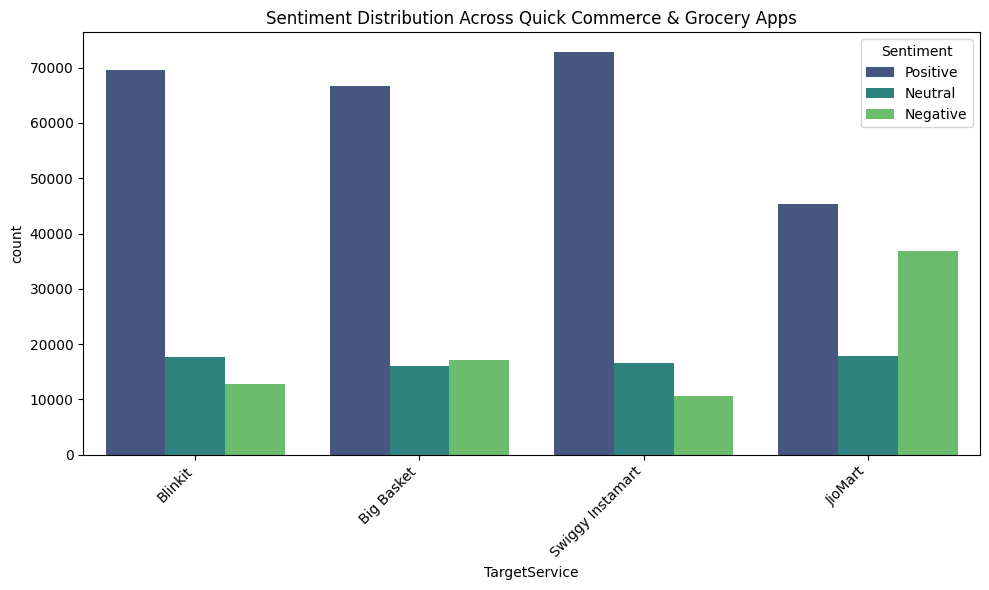

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

# Download the VADER lexicon (only needed once)
nltk.download('vader_lexicon', quiet=True)

# 1. Load the data scraped from your previous script
try:
    df = pd.read_csv('indian_quick_commerce_reviews.csv')
    print(f"Loaded {len(df)} reviews successfully.")
except FileNotFoundError:
    print("Error: 'indian_quick_commerce_reviews.csv' not found. Run the scraper script first.")
    exit()

# Drop rows where content is missing
df = df.dropna(subset=['content'])

# 2. Tag Sub-Services within the consolidated apps
# This isolates Instamart, Minutes, and Fresh feedback based on context keywords
def tag_sub_services(row):
    content = str(row['content']).lower()
    app = row['AppName']

    if "swiggy" in app.lower() and any(k in content for k in ['instamart', 'mart', 'grocery', 'groceries']):
        return 'Swiggy Instamart'
    elif "jiomart" in app.lower() and any(k in content for k in ['jio', 'mart', 'grocery', 'groceries']):
        return 'JioMart'
    elif "bigbasket" in app.lower() and any(k in content for k in ['big basket', 'BB', 'grocery', 'groceries']):
        return 'Big Basket'
    elif "zepto" in app.lower() and any(k in content for k in ['zepto', 'instant', 'grocery', 'groceries']):
        return 'Zepto'
    elif "flipkart" in app.lower() and any(k in content for k in ['minutes', 'minute', 'grocery', '10 min']):
        return 'Flipkart Minutes'
    elif "amazon" in app.lower() and any(k in content for k in ['fresh', 'now', 'grocery', 'pantry']):
        return 'Amazon Fresh'
    elif "blinkit" in app.lower() and any(k in content for k in ['blinkit','grocery', 'groceries']):
        return 'Blinkit'
    else:
        # If it doesn't mention the sub-service keyword, keep the parent or standalone name
        return app

df['TargetService'] = df.apply(tag_sub_services, axis=1)

# 3. Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

print("\nRunning sentiment analysis engine...")
# VADER polarity_scores yields a dict: {'neg': elements, 'neu': elements, 'pos': elements, 'compound': score}
# The 'compound' score ranges from -1 (extremely negative) to +1 (extremely positive)
df['compound_score'] = df['content'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Classify sentiment based on standard VADER thresholds
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['compound_score'].apply(classify_sentiment)

# 4. Show Ecosystem Insights
print("\n" + "="*50)
print("SENTIMENT BREAKDOWN BY SERVICE")
print("="*50)

summary = df.groupby('TargetService')['Sentiment'].value_counts(normalize=True).unstack().fillna(0) * 100
print(summary.round(2))

print("\n AVERAGE USER RATING (PLAY STORE SCORE) BY SERVICE")
print(df.groupby('TargetService')['score'].mean().round(2))

# 5. Quick Verification: Spot checking text matches
print("\n Sample of Classified Reviews:")
print(df[['TargetService', 'content', 'Sentiment']].head(10))

# 6. Save the final processed dataset
df.to_csv('quick_commerce_sentiment_analyzed.csv', index=False)
print("\nSaved fully processed dataset to 'quick_commerce_sentiment_analyzed.csv'")

# Optional: Generate a quick plot comparing positive vs negative breakdown
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='TargetService', hue='Sentiment', palette='viridis')
plt.title('Sentiment Distribution Across Quick Commerce & Grocery Apps')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('sentiment_comparison.png')
print("Saved comparison chart as 'sentiment_comparison.png'")